Cloning into 'PCD_Assignment3'...
remote: Enumerating objects: 14, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 14 (delta 3), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (14/14), 1.65 MiB | 6.97 MiB/s, done.
Resolving deltas: 100% (3/3), done.
image 1:


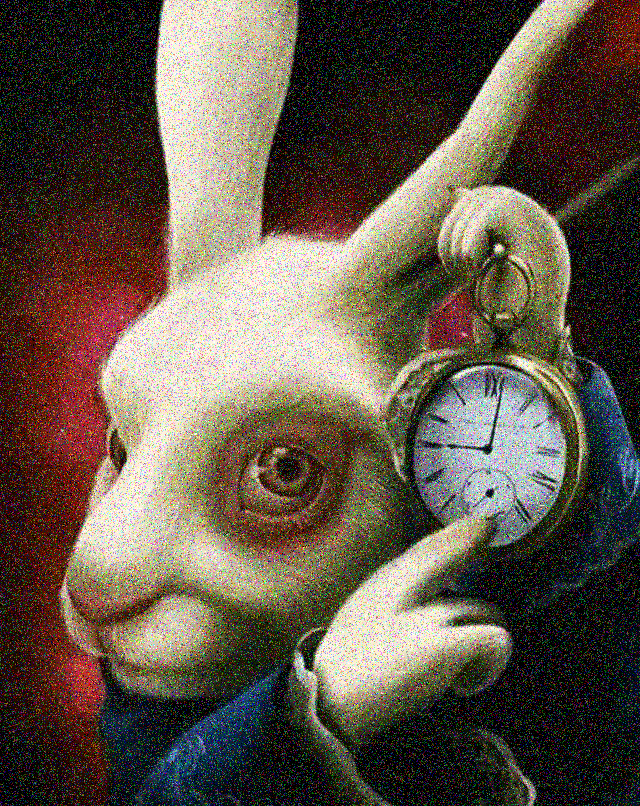

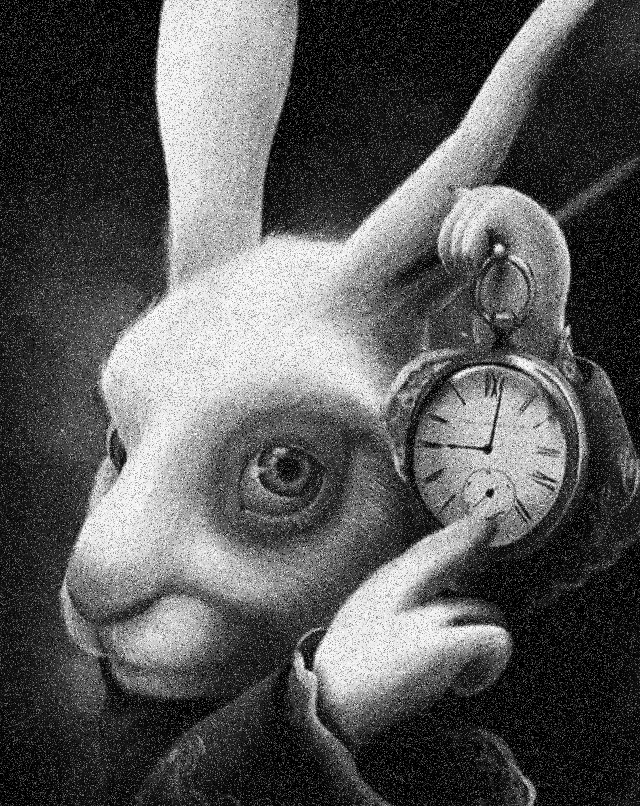

 
 
 
 
 
image 2:


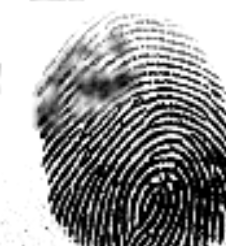

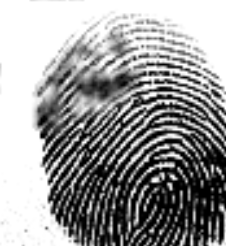

In [102]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
from skimage import data
import pandas as pd
from scipy import misc,ndimage
from PIL import Image,ImageFilter
from google.colab.patches import cv2_imshow


def spasi(): #fungsi spasi sebagai pembatas antar output supaya dapat dicerna dengan lebih jelas dan tidak berantakan
  for i in range(5):
    print(" ")

!rm -rf PCD_Assignment3
!git clone https://github.com/evanrazzanadytaputra2006-dotcom/PCD_Assignment3

image1 = cv2.imread("/content/PCD_Assignment3/white_noise_image.png")
image2 = cv2.imread("/content/PCD_Assignment3/fingerprintsbetter.png")

def resize_image(image):
  channels = image.shape[2]
  height, width = image.shape[:2]
  if height % 2 != 0:
    height = height-1
  if width % 2 != 0:
    width = width-1 #memastikan ukuran image ganjil supaya dapat diaplikasikan kernel dengan lebih mudah
  return image

def zero_padding(si):
 kernel_zero_padding = np.zeros((height + 2, width + 2), dtype=np.uint8)
 for i in range(height):
  for j in range (width):
    kernel_zero_padding[i+1, j+1] = si[i, j] #membuat 0 padding untuk image
 return kernel_zero_padding

def gray_scale(image):
  gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
  return gray_image

image1 = resize_image(image1)
gray_image1 = gray_scale(image1)
print("image 1:")
cv2_imshow(image1)
cv2_imshow(gray_image1)
spasi()

image2 = resize_image(image2)
gray_image2 = gray_scale(image2)
print("image 2:")
cv2_imshow(image2)
cv2_imshow(gray_image2)




In [103]:
def pixel_frequency(image):
  height, width = image.shape[:2]
  b, g, r = cv2.split(image)
  histogramblue = cv2.calcHist([b], [0], None, [256], [0, 256]) #memperoleh pixel frequency untuk 3 channel
  histogramgreen = cv2.calcHist([g], [0], None, [256], [0, 256])
  histogramred = cv2.calcHist([r], [0], None, [256], [0, 256])

  pixel_frequencies_blue = {}
  pixel_frequencies_green = {}
  pixel_frequencies_red = {}
  for pixel_value in range(256):
    pixel_frequencies_blue[pixel_value] = histogramblue[pixel_value]
    pixel_frequencies_green[pixel_value] = histogramgreen[pixel_value]
    pixel_frequencies_red[pixel_value] = histogramred[pixel_value]

  gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
  histogram = cv2.calcHist([gray_image], [0], None, [256], [0, 256]) #memperoleh pixel frequency untuk 1 channel saja
  image2 = gray_image

  pixel_frequencies = {}
  for pixel_value in range(256):
    pixel_frequencies[pixel_value] = histogram[pixel_value]
  return pixel_frequencies

kolom kode tersebut memanfaatkan library matplotlib untuk memperoleh jumlah dari tiap nilai pixel dari image untuk memperoleh data yang diperlukan pada otsu method.

In [104]:
#otsu method
def otsu_method(pixel_frequencies, height, width):
  threshold = 1
  threshold_list = []
  wvc_list = []

  wb_list = []
  wf_list = []
  mb_list = []
  mf_list = []
  vb_list = []
  vf_list = []
  jumlah_pixel = width*height

  while threshold < 256:
    a_weight = 0
    a_mean = 0
    b_weight = 0
    b_mean = 0
    a_variance = 0
    b_variance = 0
    for pixel_value in range(256):
    #background
      if pixel_value < threshold:
        a_weight = a_weight + pixel_frequencies[pixel_value]
        a_mean = a_mean + pixel_value * pixel_frequencies[pixel_value]
    #foreground
      else:
        b_weight = b_weight + pixel_frequencies[pixel_value]
        b_mean = b_mean + pixel_value * pixel_frequencies[pixel_value]

    weight_background = a_weight/jumlah_pixel
    weight_foreground = b_weight/jumlah_pixel
    mean_background = a_mean/a_weight if a_weight > 0 else 0
    mean_foreground = b_mean/b_weight if b_weight > 0 else 0

    for pixel_value in range(256):
    #background
      if pixel_value < threshold:
        a_variance = a_variance + (pixel_frequencies[pixel_value]*(pixel_value - mean_background)**2)
    #foreground
      else:
        b_variance = b_variance + (pixel_frequencies[pixel_value]*(pixel_value - mean_foreground)**2)
    variance_background = a_variance/a_weight if a_weight > 0 else 0
    variance_foreground = b_variance/b_weight if b_weight > 0 else 0 #reminder: maybe find more efficient code faster than O^2

    wvc_dari_threshold = weight_background * variance_background + weight_foreground * variance_foreground
    threshold_list.append(threshold)
    wvc_list.append(wvc_dari_threshold)
    wb_list.append(weight_background)
    wf_list.append(weight_foreground)
    mb_list.append(mean_background)
    mf_list.append(mean_foreground)
    vb_list.append(variance_background)
    vf_list.append(variance_foreground)

    threshold = threshold + 1

  wvc_optimal = min(wvc_list)
  threshold_optimal_index = wvc_list.index(wvc_optimal)
  return threshold_optimal_index+1

Kode diatas mendefinisikan fungsi otsu method yang akan mencari within class variance untuk tiap threshold dari range nilai pixel 1-255 dengan menggunakan while loop dan mengembalikan threshold optimal untuk within class variance terendah yang akan digunakan untuk segmentasi image dan membedakan antara foreground dengan background.

In [105]:
def segment_image(threshold_optimal, image):
  image_segmented = np.zeros((height, width, 1), dtype=np.uint8)
  gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

  for i in range(height):
    for j in range (width):
      if gray_image[i,j] < threshold_optimal:
        image_segmented[i,j] = 0
      else:
        image_segmented[i, j] = 255

  zero_padded_segmented = zero_padding(image_segmented)
  return image_segmented, zero_padded_segmented

Otsu method menggunakan segmentasi biner sehingga setelah threshold optimal diperoleh, setiap pixel yang memiliki nilai lebih kecil dari threshold akan diubah menjadi pixel hitam sedangkan pixel yang memiliki nilai sama dengan atau lebih dari threshold akan menjadi putih.

In [106]:
#dilation
def traverse_2D_array_dilation(region, kernel):
    if (region * kernel).any(): #jika salah satu input saja true, maka kembalikan true (pixel akan menjadi putih)
        return True
    return False

def dilation(si, zps):
  height, width = si.shape[:2]
  dilated_image = si.copy() #image yang akan didilasi merupakan copy dari segmented image original supaya segmented image original awal tidak terubah
  kernel = np.array([[0, 255, 0],
                     [255, 255, 255], #0 = hitam, 255 = putih
                     [0, 255, 0]])

  kernel_zero_padding = zps.copy()
  for i in range(1, height+1):
    for j in range(1, width+1):
      region = kernel_zero_padding[i-1:i+2, j-1:j+2] #membuat region 3x3 yang dicek
      if traverse_2D_array_dilation(region, kernel): #bandingkan region dengan kernel
        dilated_image[i-1, j-1] = 255

  return dilated_image





In [107]:
#erosi
def traverse_2D_array_erosion(region_array, kernel_array):
    height_r, width_r = region_array.shape[:2]
    for i in range(0, height_r):
      for j in range(0, width_r):
        if kernel_array[i, j] == 255 and region_array[i, j] != 255:
          return False #jika pada setiap posisi dimana nilai kernel bukan 0, jika nilai pixel region tidak sama dengan 255 pada posisi tersebut maka kembalikan false (pixel menjadi warna putih)
    return True

def erosi(si, zps):
  height, width = si.shape[:2]
  erosi_image = si.copy()
  kernel = np.array([[0, 255, 0],
                     [255, 255, 255],
                     [0, 255, 0]])

  kernel_zero_padding = zps.copy()

  for i in range(1, height+1):
    for j in range(1, width+1):
      region = si[i-1:i+2, j-1:j+2]
      if traverse_2D_array_erosion(region, kernel):
        erosi_image[i-1, j-1] = 255
      else:
        erosi_image[i-1, j-1] = 0

  return erosi_image

2 kolom kode diatas mendefinisikan fungsi untuk dilasi dan erosi. Dilasi bertujuan untuk memperbesar objek of interest untuk mengisi bolongan, mempertebalkan boundary, dan memperjelas image. Sedangkan erosi bertujuan untuk memperkecil object of interest agar dapat memisahkan antar objek yang sedang bersentuhan atau mereduksi noise. Pada kedua fungsi tersebut, Saya memilih kernel cross sebagai contoh sederhana untuk traversal pada erosi dan dilasi, kedua fungsi tersebut akan mengembalikan hasil dilasi dan erosi.

In [108]:
#opening dan closing
def opening(si, zps):
  a = erosi(si, zps)
  zps_erosi = zero_padding(a)
  return dilation(a, zps_erosi)

def closing(si, zps):
  a = dilation(si, zps)
  zps_dilation = zero_padding(a)
  return erosi(a, zps_dilation)

Kode diatas mendefinisikan fungsi opening dan closing. Opening merupakan metode morphological processing yang mengaplikasikan erosi pada suatu citra lalu mengaplikasikan dilasi, hal ini bertujuan untuk mengimplementasikan erosi dengan tidak destruktif, mempreservasi region foreground, dan menghapus detil-detil kecil tidak signifikan untuk menghilangkan noise. Sedangkan closing merupakan operasi yang mengaplikasikan dilasi lalu erosi pada suatu citra, hal ini bertujuan untuk mengimplementasikan dilasi dengan tidak destruktif, mempreservasi background, dan menghubungkan garis putus.

image original:


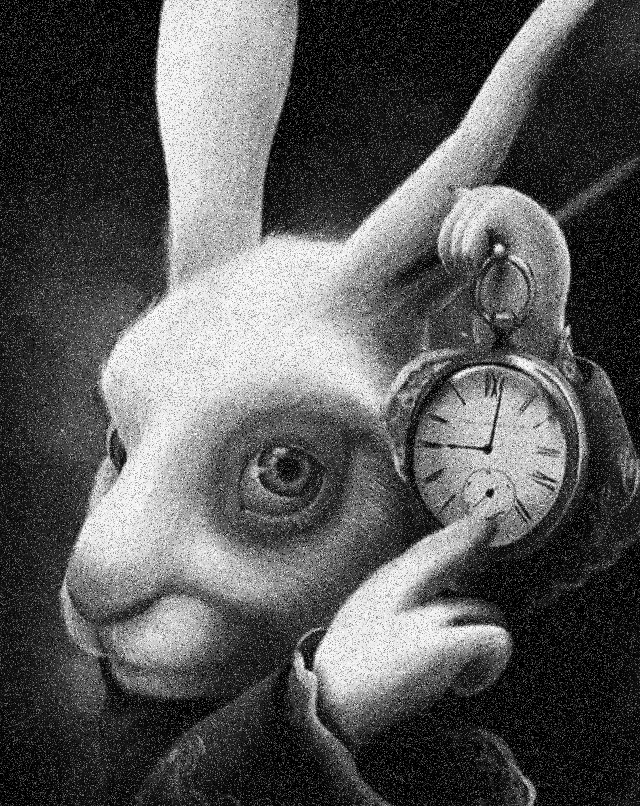

 
 
 
 
 
threshold optimal:  114


/tmp/ipython-input-1480529058.py:34: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  kernel_zero_padding[i+1, j+1] = si[i, j] #membuat 0 padding untuk image


image segmented original:


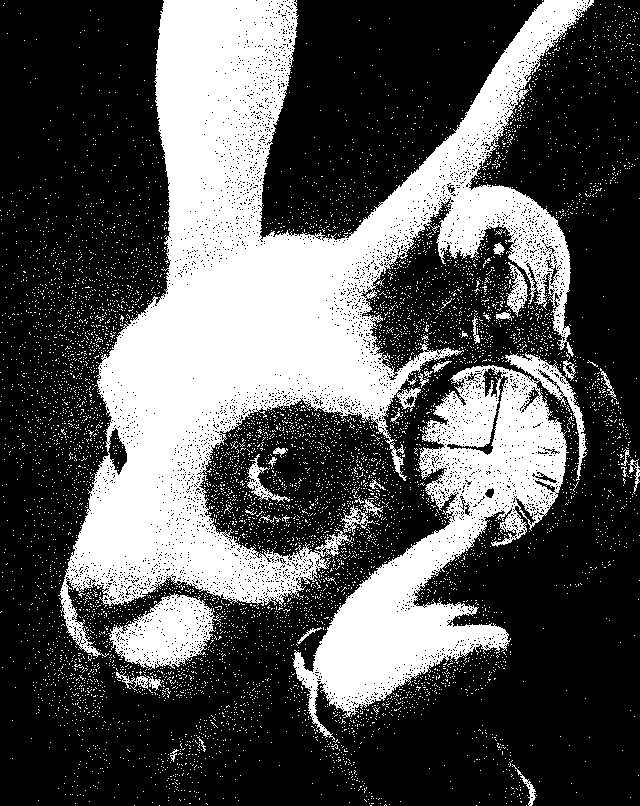

 
 
 
 
 
hasil dilasi:


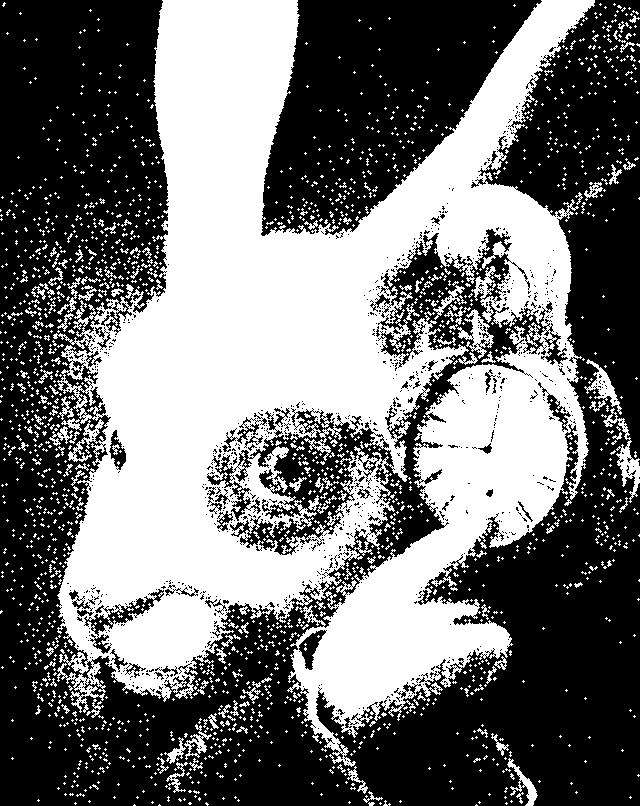

 
 
 
 
 
hasil erosi:


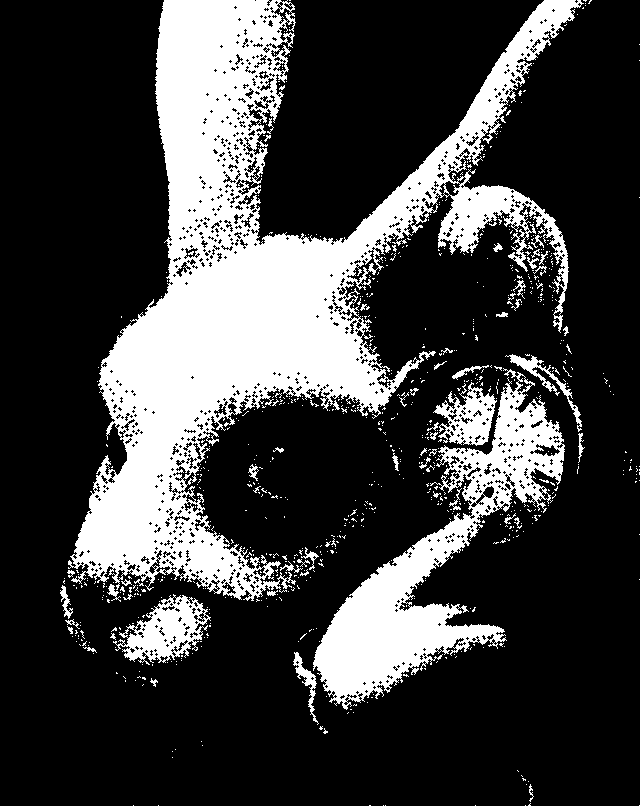

 
 
 
 
 
hasil closing:


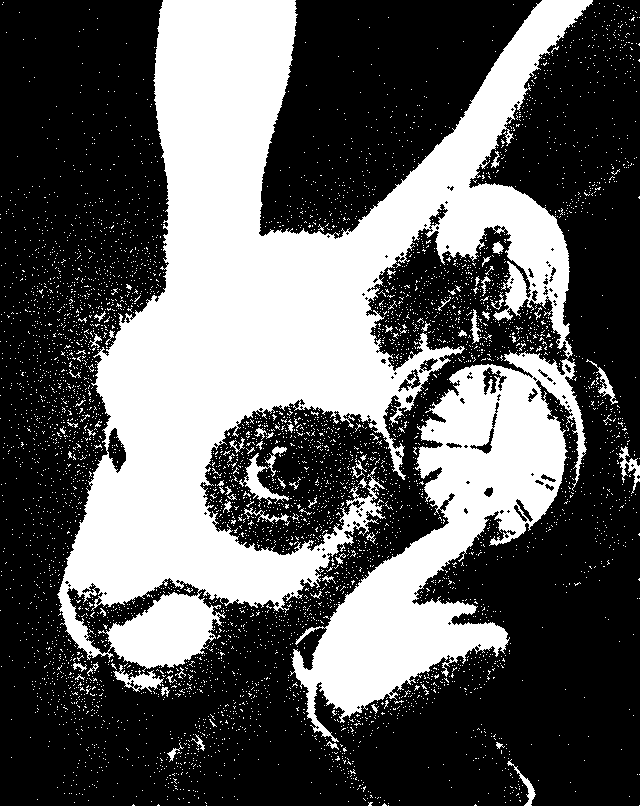

 
 
 
 
 
hasil opening:


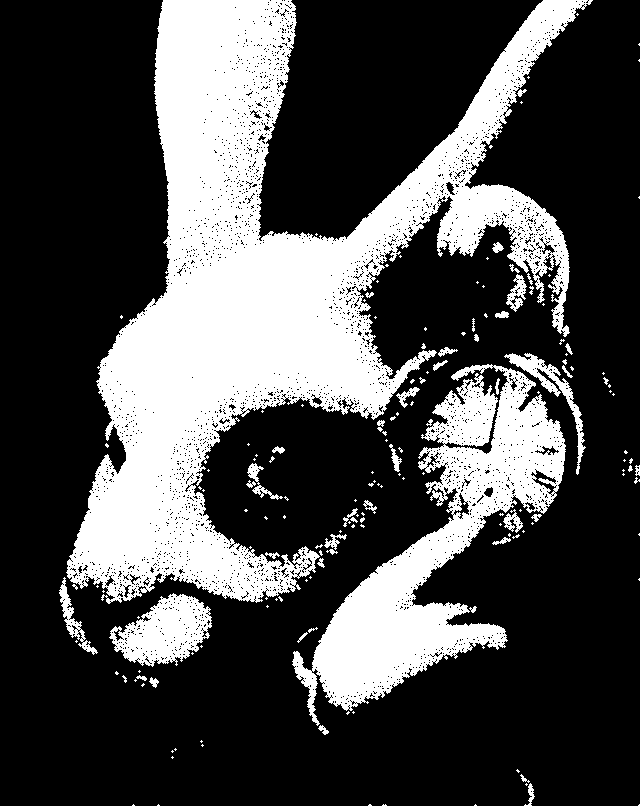

In [109]:
#testing column: white noise
print("image original:")
cv2_imshow(gray_image1)
spasi()

height, width = gray_image1.shape[:2]
pixel_freq = pixel_frequency(image1)
threshold_optimal= otsu_method(pixel_freq, height, width)
print("threshold optimal: ", threshold_optimal)

image_segmented, zero_padded_segmented = segment_image(threshold_optimal, image1)
print("image segmented original:")
cv2_imshow(image_segmented)
spasi()

print("hasil dilasi:")
dilated_image = dilation(image_segmented, zero_padded_segmented)
cv2_imshow(dilated_image)
spasi()

print("hasil erosi:")
erosi_image = erosi(image_segmented, zero_padded_segmented)
cv2_imshow(erosi_image)
spasi()

print("hasil closing:")
closing_image = closing(image_segmented, zero_padded_segmented)
cv2_imshow(closing_image)
spasi()

print("hasil opening:")
opening_image = opening(image_segmented, zero_padded_segmented)
cv2_imshow(opening_image)

Pada gambar pertama, Saya menguji efek masing-masin metode morphological processing terhadap image dengan noise yang banyak. Berdasarkan hasil yang diperoleh, Saya menganalisis bahwa:
- Dilasi tampak tidak dapat membedakan antara noise dengan objek yang penting, dilasi dapat mendeteksi outline bagian tubuh yang berbeda pada karakter seperti pada lengan jubah dan matanya yang telah diperjelas dengan lebih detil, namun metode dilasi juga memperbesar dan memperkuat setiap noise pada citra.
- erosi dapat mendeteksi noise dengan lebih baik dibandingkan dengan dilasi, namun tidak dapat membedakan bagian tubuh yang penting sebaik dilasi. Contohnya lengan jubah karakter sama sekali tidak putih dan menyatu dengan background, lalu detil pada mata juga tampaknya tidak terdeteksi sebagai objek penting dan tenggelam dalam piksel hitam
- closing juga tidak dapat mendeteksi noise sebaik erosi, namun tetap lebih baik dari dilasi. Closing tampak mendeteksi dan memisahkan objek penting lebih baik dibanding semua metode lain, contohnya outline dari lengan karakter dan angka pada jam yang dipegangnya tampak lebih jelas dibandingkan metode lain.
- opening dapat menghapus noise dan membedakannya dengan objek penting dengan lebih baik dari erosi. Hal tersebut dibuktikan dengan bintik-bintik hitam yang terlihat banyak pada wajah karakter pada hasil erosi, namun jauh lebih sedikit pada opening, hal tersebut berarti metode erosi mendeteksi beberapa bagian penting dari wajah karakter sebagai background sedangkan opening menanganinya dengan lebih baik. Opening juga dapat menguraikan objek penting dengan lebih baik dari erosi, contohnya opening mendeteksi lebih banyak piksel putih pada lengan karakter dibandingkan erosi.

Sebagai kesimpulan analisis Saya, opening merupakan metode terbaik untuk menghapus noise dari citra, sedangkan closing merupakan metode terbaik untuk mendeteksi objek penting dan memisahkannya (contohnya lengan dan mata pada hasil closing tampak paling jelas)

image original:


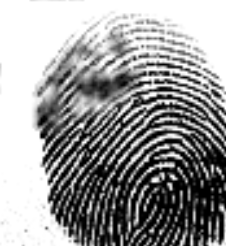

 
 
 
 
 
threshold optimal:  144
image segmented original:


/tmp/ipython-input-1480529058.py:34: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  kernel_zero_padding[i+1, j+1] = si[i, j] #membuat 0 padding untuk image


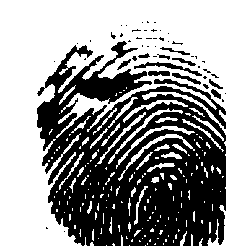

 
 
 
 
 
hasil dilasi:


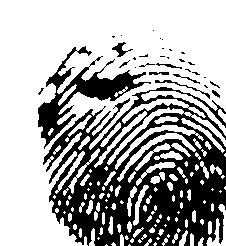

 
 
 
 
 
hasil erosi:


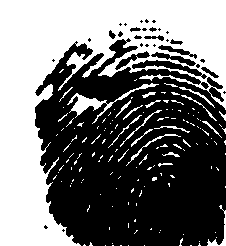

 
 
 
 
 
hasil closing:


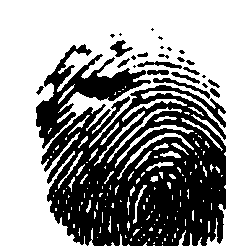

 
 
 
 
 
hasil opening:


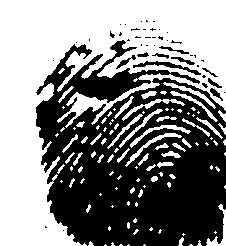

In [110]:
#testing column: fingerprints
print("image original:")
cv2_imshow(gray_image2)
spasi()

height, width = gray_image2.shape[:2]
pixel_freq = pixel_frequency(image2)
threshold_optimal= otsu_method(pixel_freq, height, width)
print("threshold optimal: ", threshold_optimal)

image_segmented, zero_padded_segmented = segment_image(threshold_optimal, image2)
print("image segmented original:")
cv2_imshow(image_segmented)
spasi()

print("hasil dilasi:")
dilated_image = dilation(image_segmented, zero_padded_segmented)
cv2_imshow(dilated_image)
spasi()

print("hasil erosi:")
erosi_image = erosi(image_segmented, zero_padded_segmented)
cv2_imshow(erosi_image)
spasi()

print("hasil closing:")
closing_image = closing(image_segmented, zero_padded_segmented)
cv2_imshow(closing_image)
spasi()

print("hasil opening:")
opening_image = opening(image_segmented, zero_padded_segmented)
cv2_imshow(opening_image)

Pada gambar kedua, Saya menguji efek masing-masing metode morphological processing terhadap image sidik jari dengan noda sedikit yang telah saya peroleh dari kaggle. Berdasarkan hasil yang diperoleh, Saya menganalisis bahwa:
- Dilasi tampak mereduksi noda dan menyambungkan garis pada sidik jari dengan sangat baik, citra sidik jari telah diperjelas sesuai teori, dan perbedaan antara suatu garis dengan garis yang di bawah atau diatasnya tampak lebih jelas meskipun ada beberapa garis yang tidak berhasil terdeteksi
- erosi tampak memperparah noda pada citra dan tidak dapat membedakan antar garis dengan baik
- closing tampak lebih baik dalam mendeteksi garis dan membedakan antar garis sidik jari dibanding dilasi, namun tampaknya closing tidak dapat mereduksi noda sebaik dilasi
- hasil opening tampak mirip dengan erosi namun pada tingkat lebih moderat, noda pada opening tidak separah pada erosi dan opening lebih baik dalam mendefinisikan perbedaan antar garis

Berdasarkan analisis tersebut, menurut Saya dilasi merupakan metode yang paling efektif dalam memperjelas citra sidik jari, hasil citra pada dilasi tampak lebih jelas dan memiliki noda jauh lebih sedikit dibanding closing.